### Imports

In [87]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import requests

### Load images from GitHub

In [88]:
def get_filename(image_id):
  return f"in{image_id:06d}.jpg"

def get_ground_truth_filename(image_id):
  return f"gt{image_id:06d}.png"

In [89]:
def load_images(url, output_folder):
  images = []

  os.makedirs(output_folder, exist_ok=True)

  for i in range(1, 1100):
      fileName = get_filename(i)

      full_path = os.path.join(output_folder, fileName)

      if not os.path.exists(full_path):
        r = requests.get(url + fileName, allow_redirects=True)
        open(full_path, "wb").write(r.content)

      img = cv2.imread(full_path, cv2.IMREAD_GRAYSCALE)
      images.append(img)

  print("Loaded", len(images), "images")
  return images

In [90]:
def load_ground_truth(url, output_folder):
  ground_truth = []

  os.makedirs(output_folder, exist_ok=True)

  for i in range(1, 1100):
      fileName = get_ground_truth_filename(i)

      full_path = os.path.join(output_folder, fileName)

      if not os.path.exists(full_path):
        r = requests.get(url + fileName, allow_redirects=True)
        open(full_path, "wb").write(r.content)

      img = cv2.imread(full_path, cv2.IMREAD_GRAYSCALE)
      ground_truth.append(img)

  print("Loaded", len(ground_truth), "images")
  return ground_truth

In [91]:
url_pedestrian = "https://raw.githubusercontent.com/vision-agh/zaw_avs_materials/main/lab02_cfd/pedestrian/input/"
url_highway = "https://raw.githubusercontent.com/vision-agh/zaw_avs_materials/main/lab02_cfd/highway/input/"
url_office = "https://raw.githubusercontent.com/vision-agh/zaw_avs_materials/main/lab02_cfd/office/input/"

img_pedestrian = load_images(url_pedestrian, "pedestrian")
img_highway = load_images(url_highway, "highway")
img_office = load_images(url_office, "office")

Loaded 1099 images
Loaded 1099 images
Loaded 1099 images


In [92]:
url_pedestrian = "https://raw.githubusercontent.com/vision-agh/zaw_avs_materials/main/lab02_cfd/pedestrian/groundtruth/"
url_highway = "https://raw.githubusercontent.com/vision-agh/zaw_avs_materials/main/lab02_cfd/highway/groundtruth/"
url_office = "https://raw.githubusercontent.com/vision-agh/zaw_avs_materials/main/lab02_cfd/office/groundtruth/"

gt_pedestrian = load_ground_truth(url_pedestrian, "pedestrian")
gt_highway = load_ground_truth(url_highway, "highway")
gt_office = load_ground_truth(url_office, "office")

Loaded 1099 images
Loaded 1099 images
Loaded 1099 images


### Buffer methods

In [103]:
def buffer_method(img_width, img_height, img_list, buf_size, buf_func=np.median):
    buffer = np.zeros((img_height, img_width, buf_size)).astype("uint8")
    buffer_counter = 0
    buffer_full = False

    results = []

    for img in img_list:
        buffer[:, :, buffer_counter] = img
        buffer_counter += 1
        if buffer_counter == buf_size:
            buffer_counter = 0
            buffer_full = True

        if buffer_full:
            result = buf_func(buffer, axis=2).astype("uint8")
            results.append(result)

    return results



### Classification metods

In [94]:
def precision(image, ground_truth):
    TP = ((image == 255) & (ground_truth == 255)).sum()
    FP = ((image == 255) & (ground_truth == 0)).sum()

    return TP / (TP + FP) if (TP + FP) > 0 else 0


In [95]:
def recall(image, ground_truth):
    TP = ((image == 255) & (ground_truth == 255)).sum()
    FN = ((image == 0) & (ground_truth == 255)).sum()

    return TP / (TP + FN) if (TP + FN) > 0 else 0

In [ ]:
def F1_score(image, ground_truth):
  precision_value = precision(image, ground_truth)
  recall_value = recall(image, ground_truth)

  if precision_value + recall_value == 0:
      return 0

  return (2 * precision_value * recall_value) / (precision_value + recall_value)

### Buffer method for pedestrians

In [104]:
img_height, img_width = img_pedestrian[0].shape
pedestrian_median = buffer_method(img_width, img_height, img_pedestrian, 60)
pedestrian_mean = buffer_method(img_width, img_height, img_pedestrian, 60, buf_func=np.mean)
pedestrian_ground_truth = gt_pedestrian

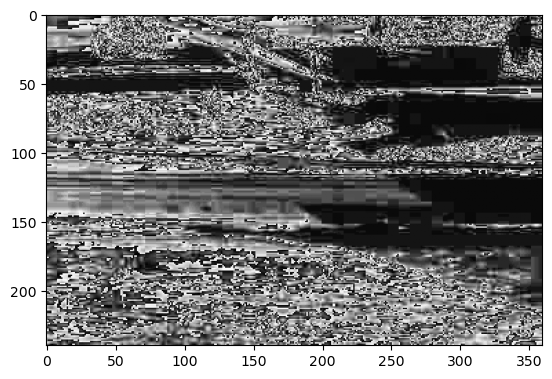

In [127]:
p_scores_median = []
r_scores_median = []
f1_scores_median = []

p_scores_mean = []
r_scores_mean = []
f1_scores_mean = []

start, end = 300, 399
for i in range(len(pedestrian_median)):
  if i >= start and i <= end:

    current_img = img_pedestrian[i].copy()
    #current_img -= pedestrian_median[i]

    plt.imshow(img_pedestrian[i])
    break

    p_scores_median.append(precision(current_img, pedestrian_ground_truth[i]))
    r_scores_median.append(recall(current_img, pedestrian_ground_truth[i]))
    f1_scores_median.append(F1_score(current_img, pedestrian_ground_truth[i]))

    p_scores_mean.append(precision(current_img, pedestrian_ground_truth[i]))
    r_scores_mean.append(recall(current_img, pedestrian_ground_truth[i]))
    f1_scores_mean.append(F1_score(current_img, pedestrian_ground_truth[i]))

In [107]:
print(sum(p_scores_median) / len(p_scores_median))
print(sum(r_scores_median) / len(r_scores_median))
print(sum(f1_scores_median) / len(f1_scores_median))
print()
print(sum(p_scores_mean) / len(p_scores_mean))
print(sum(r_scores_mean) / len(r_scores_mean))
print(sum(f1_scores_mean) / len(f1_scores_mean))

0.003581663283873398
0.86
0.0070940098907460655

2.3912166279625147e-05
0.02
4.7751274394226305e-05
